# Numerical Simulation Laboratory - Notebook 7

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

## Exercise 07.2

In [19]:
def compute_autocorrelation(data, t_lim):
    """
    Computes the autocorrelation in a dataset up to a maximum time t_lim
    """
    tmax = len(data)
    autocorr = np.empty(t_lim)
    
    avg_tot_2 = np.sum(data * data) / tmax
    avg_tot = np.sum(data) / tmax
    var_tot = avg_tot_2 - np.power(avg_tot, 2)
    
    for t in range(t_lim):
        dt = tmax - t
        num = np.sum(data[:dt]*data[t:])/dt - np.sum(data[:dt])*np.sum(data[t:])/(dt*dt)
        autocorr[t] = num / var_tot
    
    return autocorr

def error(L, data):
    """
    Computes the statistical error produced by data blocking with blocks of size L
    """
    N = int(len(data)//L)

    averages = np.array([np.sum(data[i*L:(i+1)*L]) / L for i in range(N)])
    sum_averages = np.sum(averages) / N
    sum_averages2 = np.sum(averages * averages) / N
    return np.sqrt((sum_averages2-np.power(sum_averages,2))/(N-1))

In [32]:
steps, energy_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.2_1/potential_energy.dat", usecols=(0,1), unpack=True)
energy_MD = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.2_2/potential_energy.dat", usecols=(1), unpack=True)

tmax = 2000
autocorrelation_MC = compute_autocorrelation(energy_MC, tmax)
autocorrelation_MD = compute_autocorrelation(energy_MD, tmax)

L = np.array( [n for n in range(10, 5001) if steps.size%n == 0] ) # Array of all divisors of the number of data less or equal to 5000
errors_MC = [error(int(l), energy_MC) for l in L]
errors_MD = [error(int(l), energy_MD) for l in L]

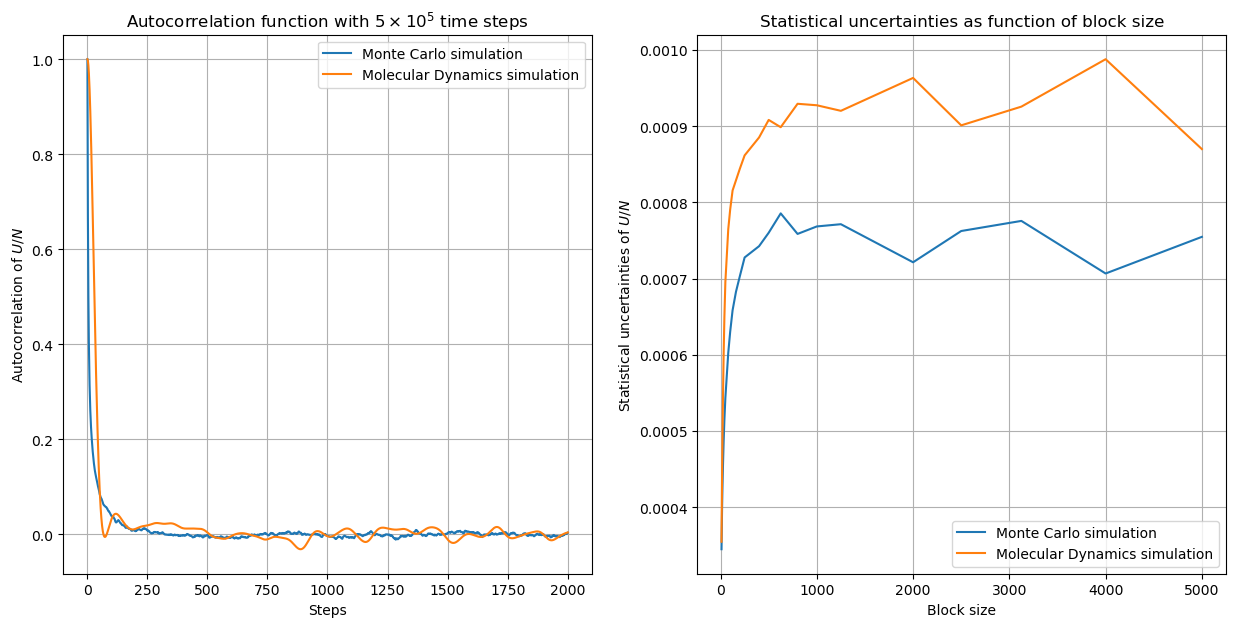

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].plot(steps[:tmax], autocorrelation_MC, label="Monte Carlo simulation")
axs[0].plot(steps[:tmax], autocorrelation_MD, label="Molecular Dynamics simulation")

axs[0].set_title("Autocorrelation function with $5\\times10^5$ time steps")
axs[0].set_ylabel("Autocorrelation of $U/N$")
axs[0].set_xlabel("Steps")

axs[1].plot(L, errors_MC, label="Monte Carlo simulation")
axs[1].plot(L, errors_MD, label="Molecular Dynamics simulation")

axs[1].set_xlabel("Block size")
axs[1].set_ylabel("Statistical uncertainties of $U/N$")
axs[1].set_title("Statistical uncertainties as function of block size")

for i in range(2):
    axs[i].legend()
    axs[i].grid();


Both simulations were equilibrated by completing $40000$ time steps. The starting temperature of the MD simulation is $T=2$, which after equilibration becomes $T_\text{eff}=1.113\pm0.002$, and the time step $dt=0.001$. The temperature of the MC simulation is $T=1.1$ and the step $dt=0.1$, which sets the acceptance rate at about $50\%$. The density is $\rho=0.8$ and the cut-off radius is $r_c=2.5$ for both simulations.

The figure shows that for both types of simulation the autocorrelation becomes negligible after about $200/300$ time steps, after which it starts fluctuating around zero. From this the correlation time can be deduced to be $\tau_c\approx200$. To ensure statistically independent averages values inside each block it is necessary that the block size $L\gg \tau_c$, which means that the block size should be at least $L=1000$. This is confirmed by looking at the statistical uncertainties as a function of $L$. When $L$ is small the uncertainties are underestimated because the averages of different blocks are heavily correlated. After $L\approx1000$ the uncertainties fluctuate around a plateau because the block averages become uncorrelated. The fluctuation after $L\gg \tau_c$ are given by the fact that by increasing the block size there are fewer total blocks on which to average over. The uncertainties in the figure where calculated only for block sizes that are divisors of the total number of data.

The autocorrelation function in the molecular dynamics simulation has larger fluctuations that the one in the Monte Carlo simulation. This is because the autocorrelation in the MD simulation is restrained by the fact that the system needs more time to travel to uncorrelated configurations since it has to follow physical trajectories. The fact that the molecular dynamics simulation explores the phase space less effectively is also the cause of the larger value at which the statistical uncertainties converge.

## Exercise 07.4

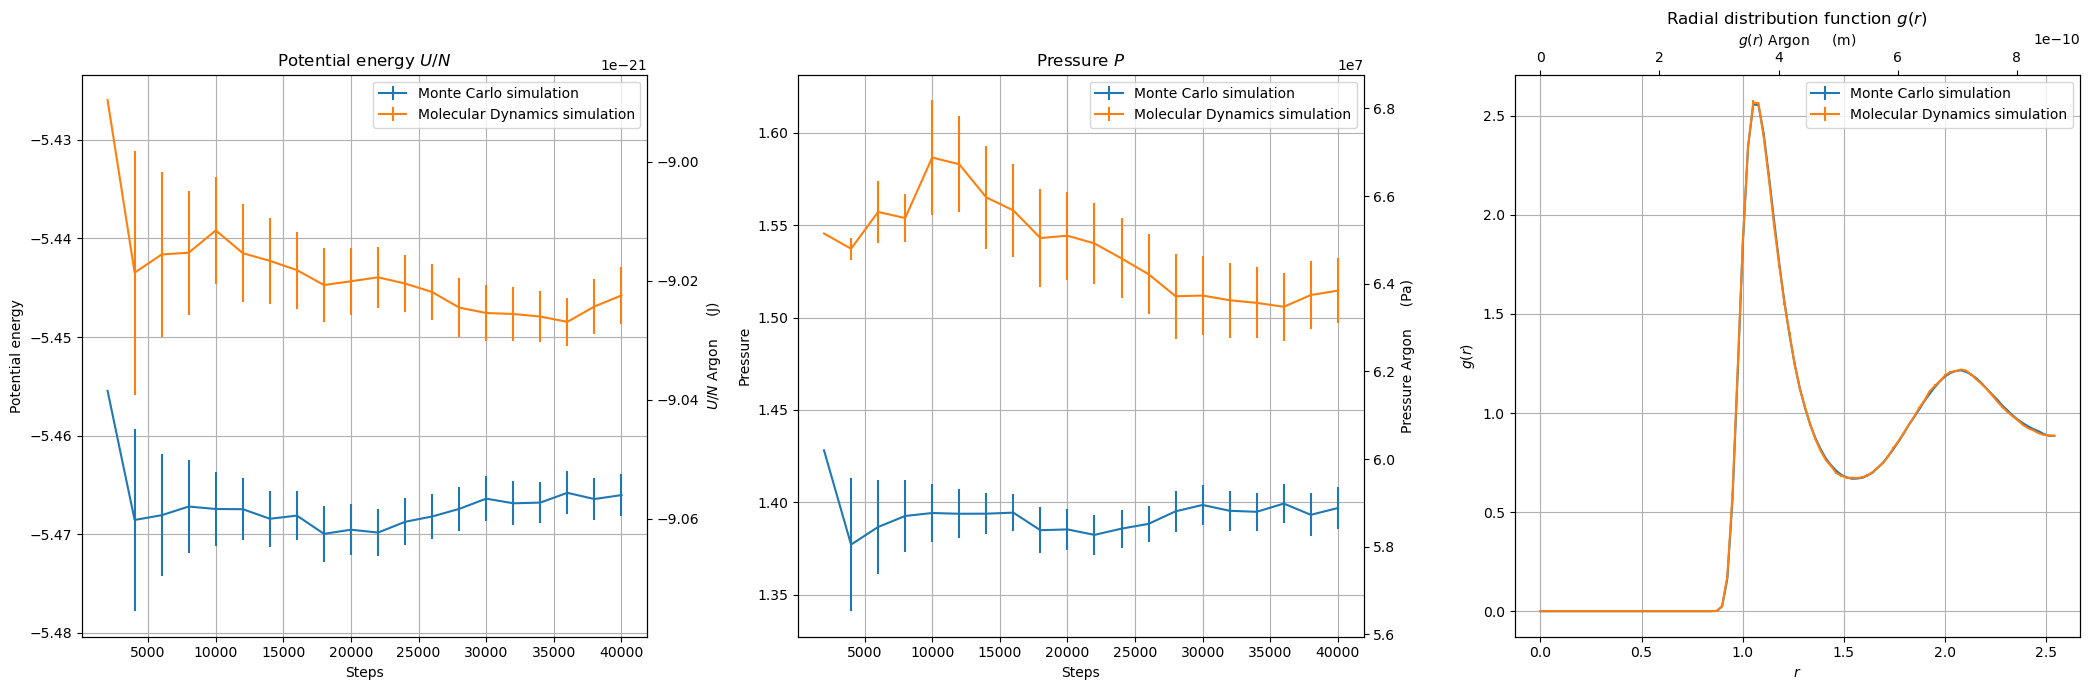

In [46]:
energy_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/potential_energy.dat", usecols=(2,3))
pressure_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/pressure.dat", usecols=(2,3))
data_gofr_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/gofr.dat")
r, gofr_MC = data_gofr_MC[:,0], data_gofr_MC[:,1:]
blocks = (np.arange(len(energy_MC)) + 1) * 2000

energy_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/potential_energy.dat", usecols=(2,3))
pressure_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/pressure.dat", usecols=(2,3))
gofr_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/gofr.dat", usecols=(1,2))

# Argon values
sigma = 0.34e-9
epsilon = 120 * 1.380649e-23
m = 39.948 * 1.660539e-27

fig, axs = plt.subplots(1, 3, figsize=(21,7))
axs = axs.flatten()

axs[0].errorbar(blocks, energy_MC[:,0], yerr=energy_MC[:,1], label="Monte Carlo simulation")
axs[0].errorbar(blocks, energy_DM[:,0], yerr=energy_DM[:,1], label="Molecular Dynamics simulation")
ax2 = axs[0].twinx()
ax2.set_ylim(np.array(axs[0].get_ylim())*epsilon)
ax2.set_ylabel("$U/N$ Argon     (J)")

axs[1].errorbar(blocks, pressure_MC[:,0], yerr=pressure_MC[:,1], label="Monte Carlo simulation")
axs[1].errorbar(blocks, pressure_DM[:,0], yerr=pressure_DM[:,1], label="Molecular Dynamics simulation")
ax2 = axs[1].twinx()
ax2.set_ylim(np.array(axs[1].get_ylim())*epsilon/(sigma**3))
ax2.set_ylabel("Pressure Argon     (Pa)")

axs[2].errorbar(r, gofr_MC[:,0], yerr=gofr_MC[:,1], label="Monte Carlo simulation")
axs[2].errorbar(r, gofr_DM[:,0], yerr=gofr_DM[:,1], label="Molecular Dynamics simulation")
ax2 = axs[2].twiny()
ax2.set_xlim(np.array(axs[2].get_xlim())*sigma)
ax2.set_xlabel("$g(r)$ Argon     (m)")

x_labels = ["Steps", "Steps", "$r$"]
y_labels = ["Potential energy", "Pressure", "$g(r)$"]
titles = ["Potential energy $U/N$", "Pressure $P$", "Radial distribution function $g(r)$"]

for i, ax in enumerate(axs):
    ax.set_xlabel(x_labels[i])
    ax.set_ylabel(y_labels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend();
plt.tight_layout();

Before the simulation 20000 equilibration steps were executed. The starting conditions of the simulations are the same of the previous exercise.

Both the potential energy and the pressure converge to close but not compatible values. This is because the temperature of the two simulation are slightly different since MD doesn't work at fixed temperature so the equilibrium temperature $T_\text{eff}=1.113\pm0.002$ is different from $T=1.1$ of the MC simulation. The radial distribution function is very similar in both simulations and follows the typical form of a radial distribution in a liquid, which fluctuates around $1$ with increasingly smaller fluctuations, as it is expected because in a liquid particles don't have any long range correlation.